In [1]:
import pandas as pd
import numpy as np
from pycaret.classification import *

In [ ]:
df = pd.read_csv("img_path_and_clinical_info.csv")

In [5]:
import pandas as pd
from sklearn.decomposition import PCA

# Select columns that start with "img"
img_cols = [c for c in df.columns if c.startswith("img")]

# Apply PCA to reduce dimensionality (41 components)
pca = PCA(n_components=41, random_state=42)
img_pca = pca.fit_transform(df[img_cols])

# Define column names after PCA
pca_cols = [f"img_pca_{i}" for i in range(41)]

# Convert PCA output to a DataFrame
img_pca_df = pd.DataFrame(img_pca, columns=pca_cols, index=df.index)

# Drop original image features and append PCA features
df_pca = df.drop(columns=img_cols)
df_pca = pd.concat([df_pca, img_pca_df], axis=1)

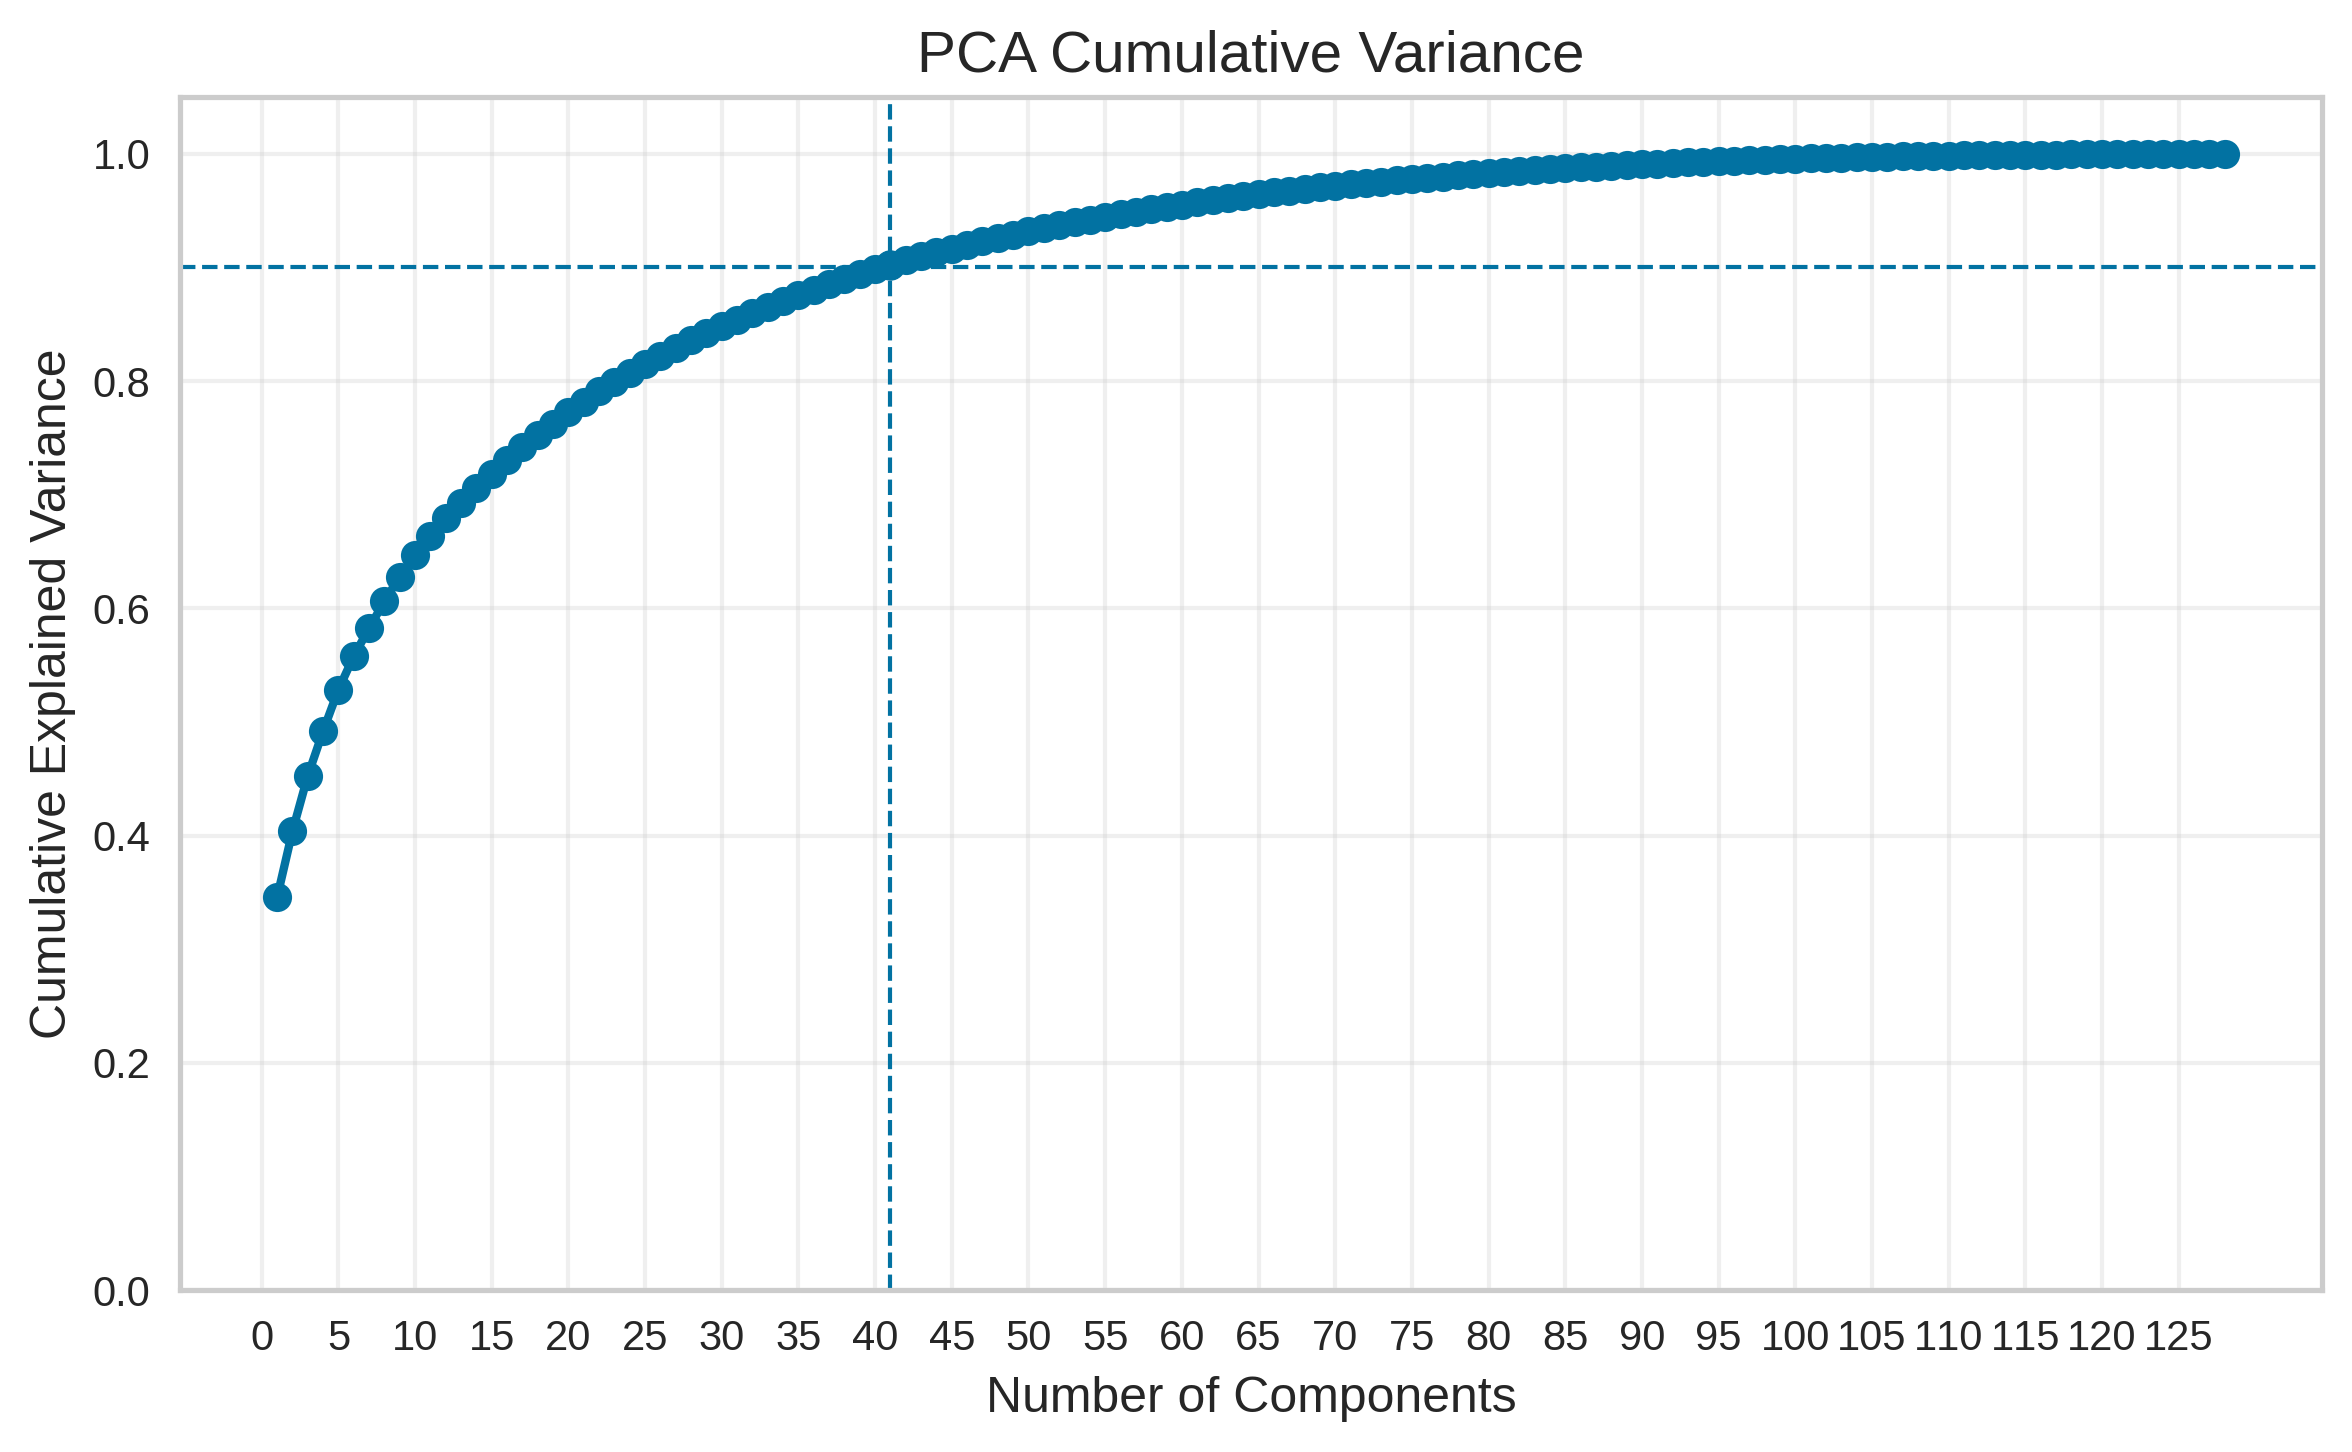

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Perform PCA
pca_full = PCA(random_state=42)
pca_full.fit(df[img_cols])

# Cumulative explained variance
cum_var = pca_full.explained_variance_ratio_.cumsum()

# Find the component index reaching 90%
n_90 = np.argmax(cum_var >= 0.90) + 1  # x starts from 1

# Plot
plt.figure(figsize=(8, 5), dpi=300)

x = np.arange(1, len(cum_var) + 1)
plt.plot(x, cum_var, marker='o', linewidth=2)

# Horizontal threshold line (90%)
plt.axhline(0.9, linestyle='--', linewidth=1)

# Vertical line at the corresponding component number
plt.axvline(n_90, linestyle='--', linewidth=1)

# Mark the intersection point
plt.scatter(n_90, cum_var[n_90 - 1])

# Labels
plt.xlabel("Number of Components", fontsize=12)
plt.ylabel("Cumulative Explained Variance", fontsize=12)
plt.title("PCA Cumulative Variance", fontsize=14)

# Ticks
plt.xticks(np.arange(0, len(cum_var)+1, 5))
plt.yticks(np.linspace(0, 1, 6))

plt.ylim(0, 1.05)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
df = df_pca

In [ ]:
train_ids = pd.read_csv("img_path_and_clinical_info_train.csv")
train_id = train_ids["patient_id"].to_list()

In [ ]:
test_ids = pd.read_csv("img_path_and_clinical_info_test.csv")
test_id = test_ids["patient_id"].to_list()

In [18]:
print(df.columns)

Index(['Unnamed: 0', 'path', 'label_x', 'patient_id', 'local_patient_id',
       'WBC', 'PLT', 'CRP', 'T-Bil', 'AST', 'ALT', 'γGTP', 'ALP', 'Cre',
       'PT-INR', 'src', 'label_y', 'img_pca_0', 'img_pca_1', 'img_pca_2',
       'img_pca_3', 'img_pca_4', 'img_pca_5', 'img_pca_6', 'img_pca_7',
       'img_pca_8', 'img_pca_9', 'img_pca_10', 'img_pca_11', 'img_pca_12',
       'img_pca_13', 'img_pca_14', 'img_pca_15', 'img_pca_16', 'img_pca_17',
       'img_pca_18', 'img_pca_19', 'img_pca_20', 'img_pca_21', 'img_pca_22',
       'img_pca_23', 'img_pca_24', 'img_pca_25', 'img_pca_26', 'img_pca_27',
       'img_pca_28', 'img_pca_29', 'img_pca_30', 'img_pca_31', 'img_pca_32',
       'img_pca_33', 'img_pca_34', 'img_pca_35', 'img_pca_36', 'img_pca_37',
       'img_pca_38', 'img_pca_39', 'img_pca_40'],
      dtype='object')


In [19]:
train_df = df[df["patient_id"].isin(train_id)].copy()

In [20]:
test_df = df[df["patient_id"].isin(test_id)].copy()

In [21]:
df_estim = df.drop(
    ['Unnamed: 0', 'patient_id', 'local_patient_id', 'src', 'label_y'],
    axis=1
)

# Delete the column containing “img”
df_estim = df_estim.loc[:, ~df_estim.columns.str.contains('img')]

In [24]:
train_estim = train_df

In [26]:
test_df = test_df.drop(
    ['Unnamed: 0', 'patient_id', 'local_patient_id', 'src', 'label_y'],
    axis=1
)

# Delete the column containing “img”
test_estim = test_df

In [28]:
df_estim["label_x"].value_counts()

,count
label_x,
1,100
0,99


In [30]:
patient_ids = df_estim["path"].copy()

X = df_estim.drop(columns=["path"])

In [ ]:
X

,label_x,WBC,PLT,CRP,T-Bil,AST,ALT,γGTP,ALP,Cre,PT-INR
0,0,-0.518660,0.808068,-0.684757,-0.657096,-0.317251,-0.319587,-0.555147,0.498105,-0.521672,-0.380524
1,0,-0.974791,0.133618,-0.691023,-0.458172,-0.356454,-0.262354,-0.413680,-0.495753,-0.053320,-0.584285
2,0,-0.049564,0.841238,-0.687890,-0.358710,-0.356454,-0.331034,-0.510473,-0.463694,0.216883,-0.227703
3,0,-0.725313,2.002176,-0.675358,-0.856020,-0.366255,-0.342480,-0.436017,0.722524,-0.161401,-0.074882
4,0,-0.762637,0.122562,-0.693112,-0.458172,-0.248645,-0.273801,-0.130746,-0.372857,0.324964,-0.686166
...,...,...,...,...,...,...,...,...,...,...,...
194,1,1.490518,-1.480638,-0.616875,-0.557634,-0.238845,-0.273801,-0.450908,-0.607963,1.531872,0.791103
195,1,-0.632987,-0.319700,0.527720,-0.657096,0.143385,0.309972,0.569145,1.230140,0.487086,-0.125823
196,1,0.993527,0.222071,0.790893,-0.955482,-0.405458,-0.388266,-0.525365,-0.875129,9.764064,-0.074882
197,1,0.771551,-1.071546,1.669181,0.238062,-0.121235,-0.216568,-0.346669,0.460701,2.522617,0.689222


In [31]:
train_patient_ids = train_estim["path"].copy()
train_X = train_estim.drop(columns=["path"])

test_patient_ids = test_estim["path"].copy()
test_X = test_estim.drop(columns=["path"])

In [53]:
train_X.head()

,label_x,WBC,PLT,CRP,T-Bil,AST,ALT,γGTP,ALP,Cre,...,img_pca_31,img_pca_32,img_pca_33,img_pca_34,img_pca_35,img_pca_36,img_pca_37,img_pca_38,img_pca_39,img_pca_40
0,0,-0.518660,0.808068,-0.684757,-0.657096,-0.317251,-0.319587,-0.555147,0.498105,-0.521672,...,0.328033,-0.016958,0.124569,0.236769,-0.195337,0.636992,-0.106784,-0.009489,0.094419,0.259194
2,0,-0.049564,0.841238,-0.687890,-0.358710,-0.356454,-0.331034,-0.510473,-0.463694,0.216883,...,-0.202721,0.232947,-0.333149,0.143717,0.296125,0.043453,0.200822,-0.063723,0.110432,-0.325780
4,0,-0.762637,0.122562,-0.693112,-0.458172,-0.248645,-0.273801,-0.130746,-0.372857,0.324964,...,-0.287481,-0.204252,0.460522,-0.116503,0.027380,-0.179995,-0.249277,0.116557,0.030348,-0.108708
7,0,-1.247841,0.244184,-0.614786,-0.756558,0.457010,1.076890,-0.510473,-0.538500,-0.413591,...,0.087299,-0.192407,0.053970,-0.397609,-0.130775,-0.059542,0.200587,-0.106814,-0.274163,0.028222
8,0,-1.575894,-0.463435,-0.654471,-0.955482,-0.278048,-0.216568,-0.272213,-0.602620,0.180856,...,0.262205,-0.085297,-0.342299,0.261947,-0.014797,-0.195213,-0.164290,-0.041039,-0.004891,0.021414


In [54]:
test_X.head()

,label_x,WBC,PLT,CRP,T-Bil,AST,ALT,γGTP,ALP,Cre,...,img_pca_31,img_pca_32,img_pca_33,img_pca_34,img_pca_35,img_pca_36,img_pca_37,img_pca_38,img_pca_39,img_pca_40
1,0,-0.974791,0.133618,-0.691023,-0.458172,-0.356454,-0.262354,-0.413680,-0.495753,-0.053320,...,-0.025479,0.080745,0.761968,-0.299035,0.046585,0.422430,0.020044,-0.043200,0.136728,0.390642
3,0,-0.725313,2.002176,-0.675358,-0.856020,-0.366255,-0.342480,-0.436017,0.722524,-0.161401,...,0.573488,-0.338606,-0.189577,-0.043421,0.259449,0.191695,-0.453389,-0.216510,-0.072736,-0.078810
5,0,-1.116227,1.283500,-0.683713,-0.955482,-0.317251,-0.353927,-0.540256,-0.453007,-0.809889,...,0.063778,-0.660787,-0.306863,0.243327,0.234764,0.173789,0.141932,-0.114364,0.121080,-0.182879
6,0,-0.149747,-0.529775,-0.490510,-0.657096,-0.307450,-0.342480,-0.532810,-0.404917,-0.539686,...,0.278206,0.374833,0.530760,0.257091,0.129820,-0.004243,-0.054382,0.238684,-0.517952,0.237886
11,0,-0.361901,0.620107,-0.689979,-0.557634,-0.297649,-0.262354,0.137298,0.407268,-0.557699,...,0.122424,0.499077,-0.339127,-0.316105,0.143949,0.253777,-0.289955,0.148006,0.239798,0.393367


# Comparison and Selection of Predictive Models




In [32]:
clf = setup(
    data=train_X,
    target="label_x",
    test_data=test_X,
    fold_strategy="stratifiedkfold",
    fold=5,
    session_id=42,
    normalize=True
)

,Description,Value
0,Session id,42
1,Target,label_x
2,Target type,Binary
3,Original data shape,"(199, 52)"
4,Transformed data shape,"(199, 52)"
5,Transformed train set shape,"(139, 52)"
6,Transformed test set shape,"(60, 52)"
7,Numeric features,51
8,Preprocess,True
9,Imputation type,simple


In [33]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9500,0.9857,0.9286,0.9690,0.9475,0.9000,0.9020,0.2480
et,Extra Trees Classifier,0.9497,0.9893,0.9143,0.9857,0.9469,0.8995,0.9042,0.1940
lightgbm,Light Gradient Boosting Machine,0.9354,0.9734,0.9000,0.9733,0.9325,0.8709,0.8773,0.1200
lr,Logistic Regression,0.9349,0.9724,0.9000,0.9713,0.9321,0.8699,0.8755,2.1800
ada,Ada Boost Classifier,0.9280,0.9586,0.9000,0.9596,0.9263,0.8562,0.8625,0.1660
gbc,Gradient Boosting Classifier,0.9140,0.9464,0.8857,0.9424,0.9115,0.8281,0.8322,0.3120
xgboost,Extreme Gradient Boosting,0.9140,0.9723,0.8857,0.9426,0.9121,0.8281,0.8316,0.1380
nb,Naive Bayes,0.9138,0.9779,0.8857,0.9405,0.9110,0.8275,0.8307,0.0780
ridge,Ridge Classifier,0.8992,0.9608,0.8143,0.9846,0.8890,0.7985,0.8131,0.0480
lda,Linear Discriminant Analysis,0.8992,0.9588,0.8143,0.9846,0.8890,0.7985,0.8131,0.0460


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

In [34]:
model = create_model('et')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.8929,0.9566,0.7857,1.0000,0.8800,0.7857,0.8044
2,0.9286,0.9898,0.9286,0.9286,0.9286,0.8571,0.8571
3,0.9643,1.0000,0.9286,1.0000,0.9630,0.9286,0.9309
4,0.9630,1.0000,0.9286,1.0000,0.9630,0.9260,0.9286
Mean,0.9497,0.9893,0.9143,0.9857,0.9469,0.8995,0.9042
Std,0.0363,0.0168,0.0700,0.0286,0.0404,0.0727,0.0673


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [35]:
tuned_model = tune_model(model, n_iter = 15, optimize = 'Accuracy')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9643,1.0000,0.9286,1.0000,0.9630,0.9286,0.9309
1,0.8929,0.9643,0.7857,1.0000,0.8800,0.7857,0.8044
2,0.9286,0.9949,0.9286,0.9286,0.9286,0.8571,0.8571
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Mean,0.9571,0.9918,0.9286,0.9857,0.9543,0.9143,0.9185
Std,0.0416,0.0139,0.0782,0.0286,0.0457,0.0833,0.0777


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [36]:
evaluate_model(tuned_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9500,0.9856,1.0000,0.9091,0.9524,0.9000,0.9045


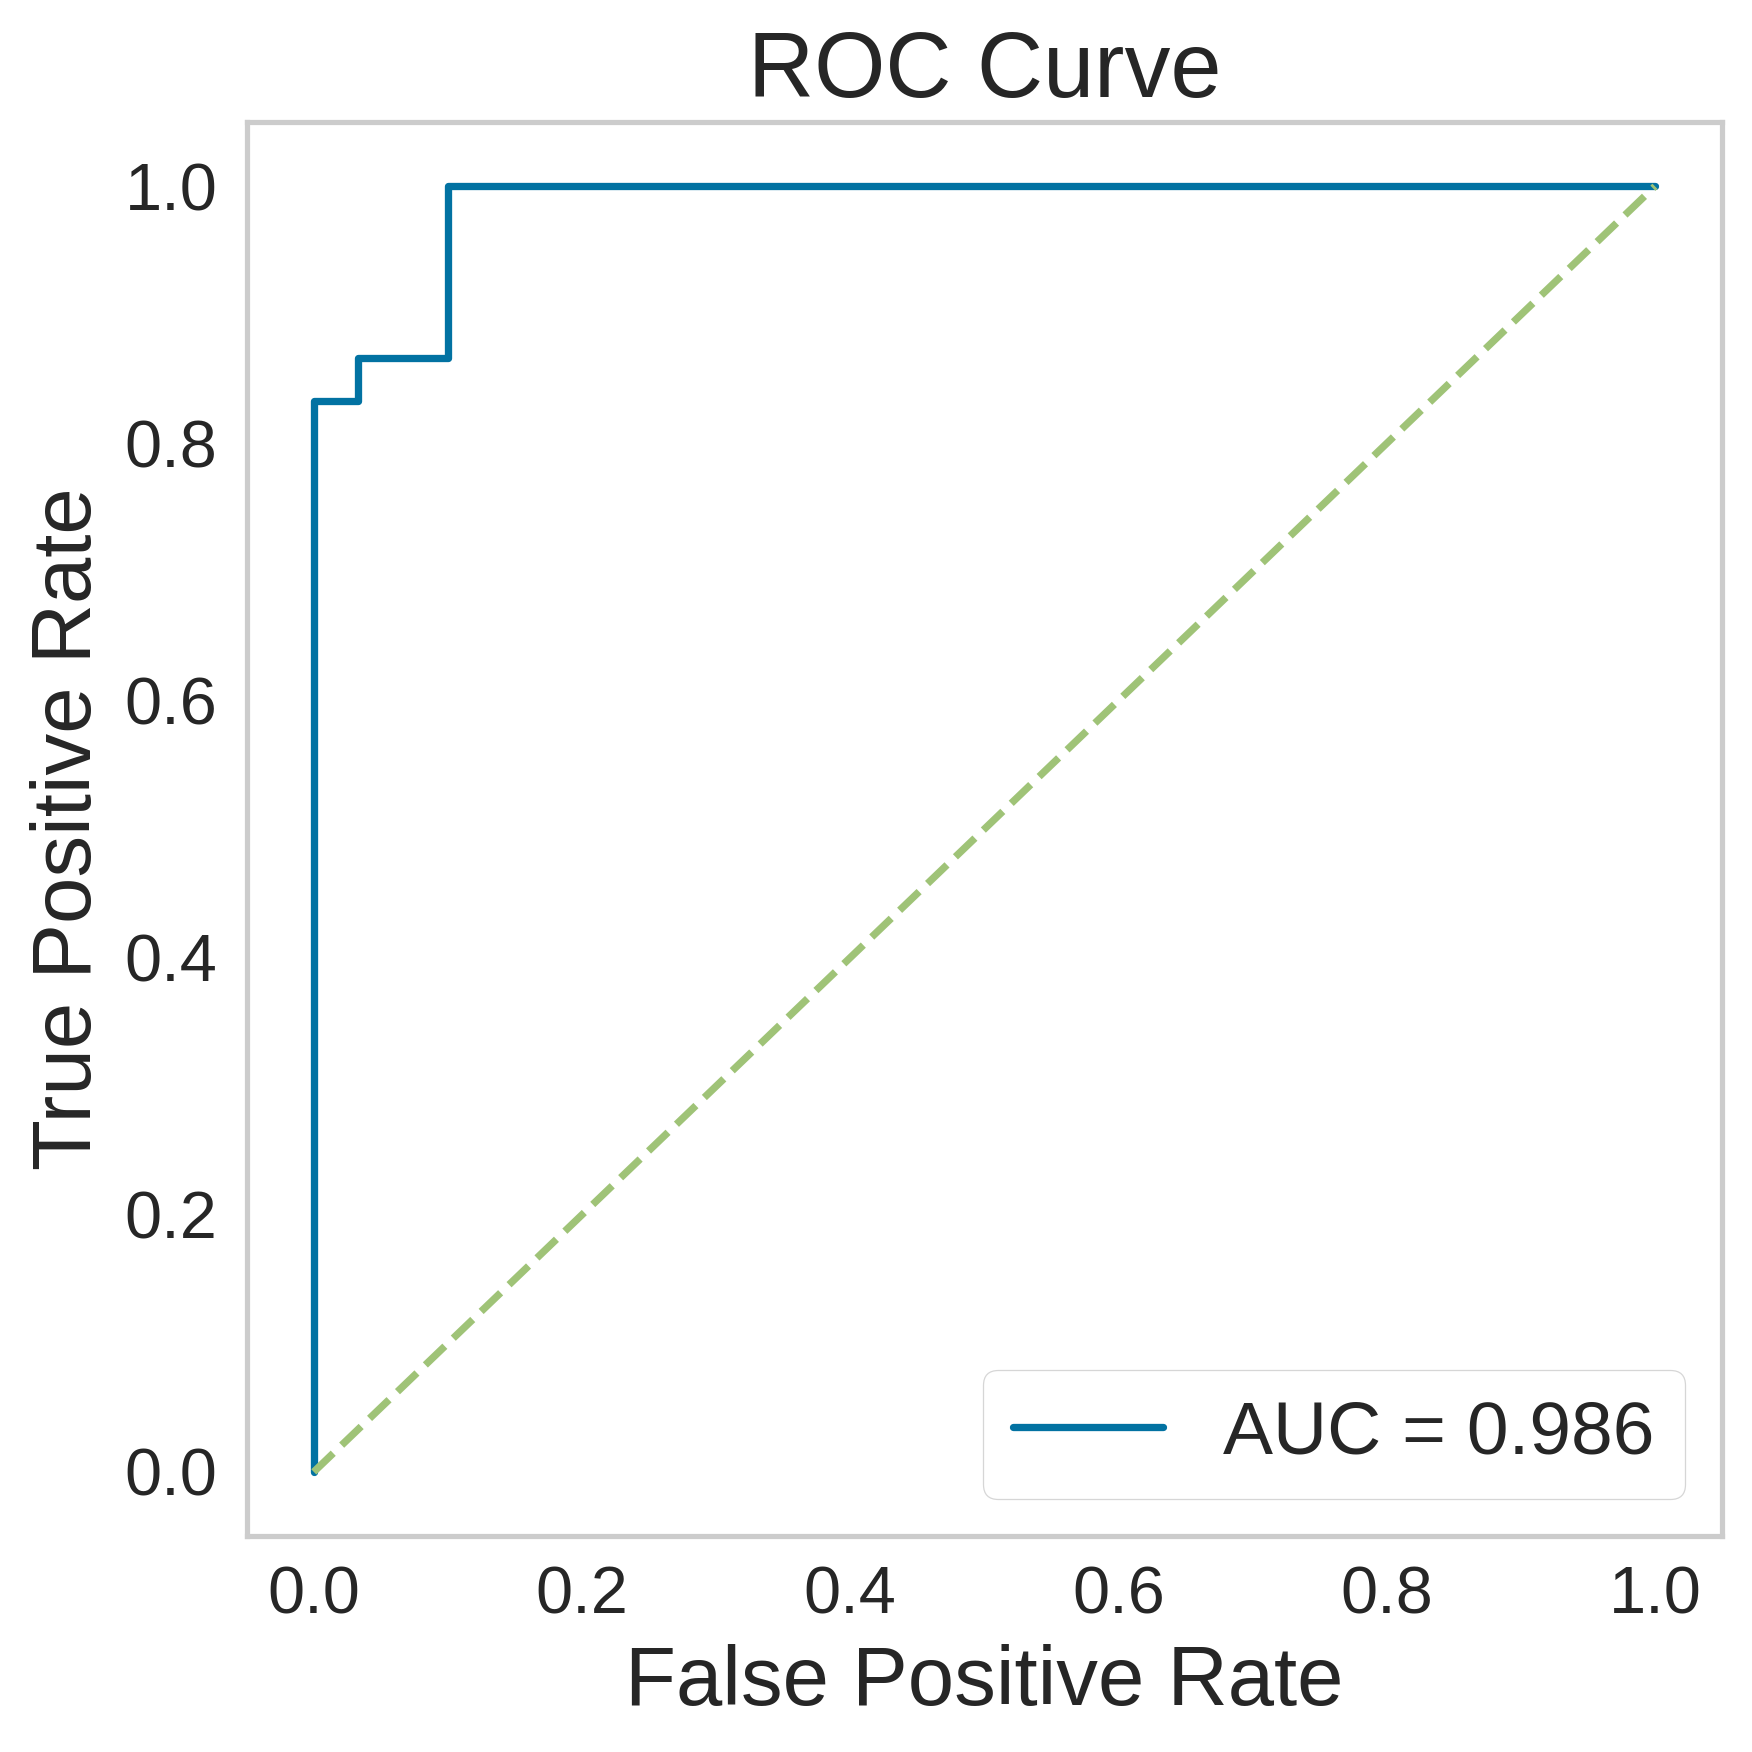

In [40]:
from pycaret.classification import predict_model
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# ===== test prediction =====
pred = predict_model(tuned_model, raw_score=True)


y_true = pred["label_x"]
y_score = pred["prediction_score_1"]

# ===== ROC =====
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# ===== plot =====
plt.figure(figsize=(6,6), dpi=300)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate", fontsize=20)
plt.ylabel("True Positive Rate", fontsize=20)
plt.title("ROC Curve", fontsize=22)
plt.tick_params(axis='both', labelsize=16)
plt.legend(fontsize=18, loc="lower right", frameon=True)
plt.grid()

plt.tight_layout()
plt.show()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9500,0.9856,1.0000,0.9091,0.9524,0.9000,0.9045


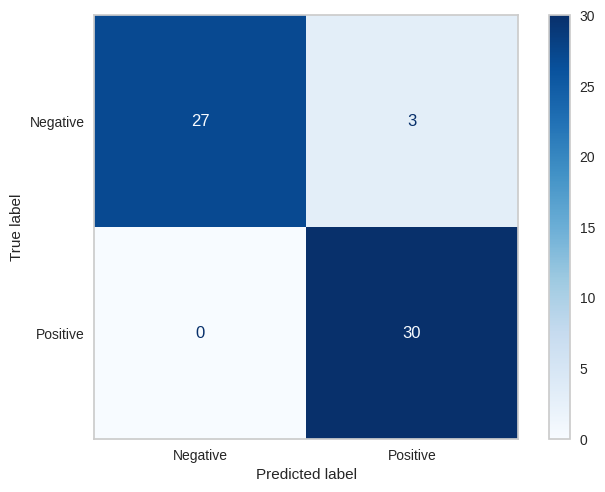

In [41]:
from pycaret.classification import predict_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions using the PyCaret model
pred_df = predict_model(tuned_model)

# Extract true labels and predicted labels
y_true = pred_df["label_x"]        # Ground truth labels
y_pred = pred_df["prediction_label"]

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix (consistent with your style)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive'],
)

disp.plot(cmap=plt.cm.Blues)
# plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

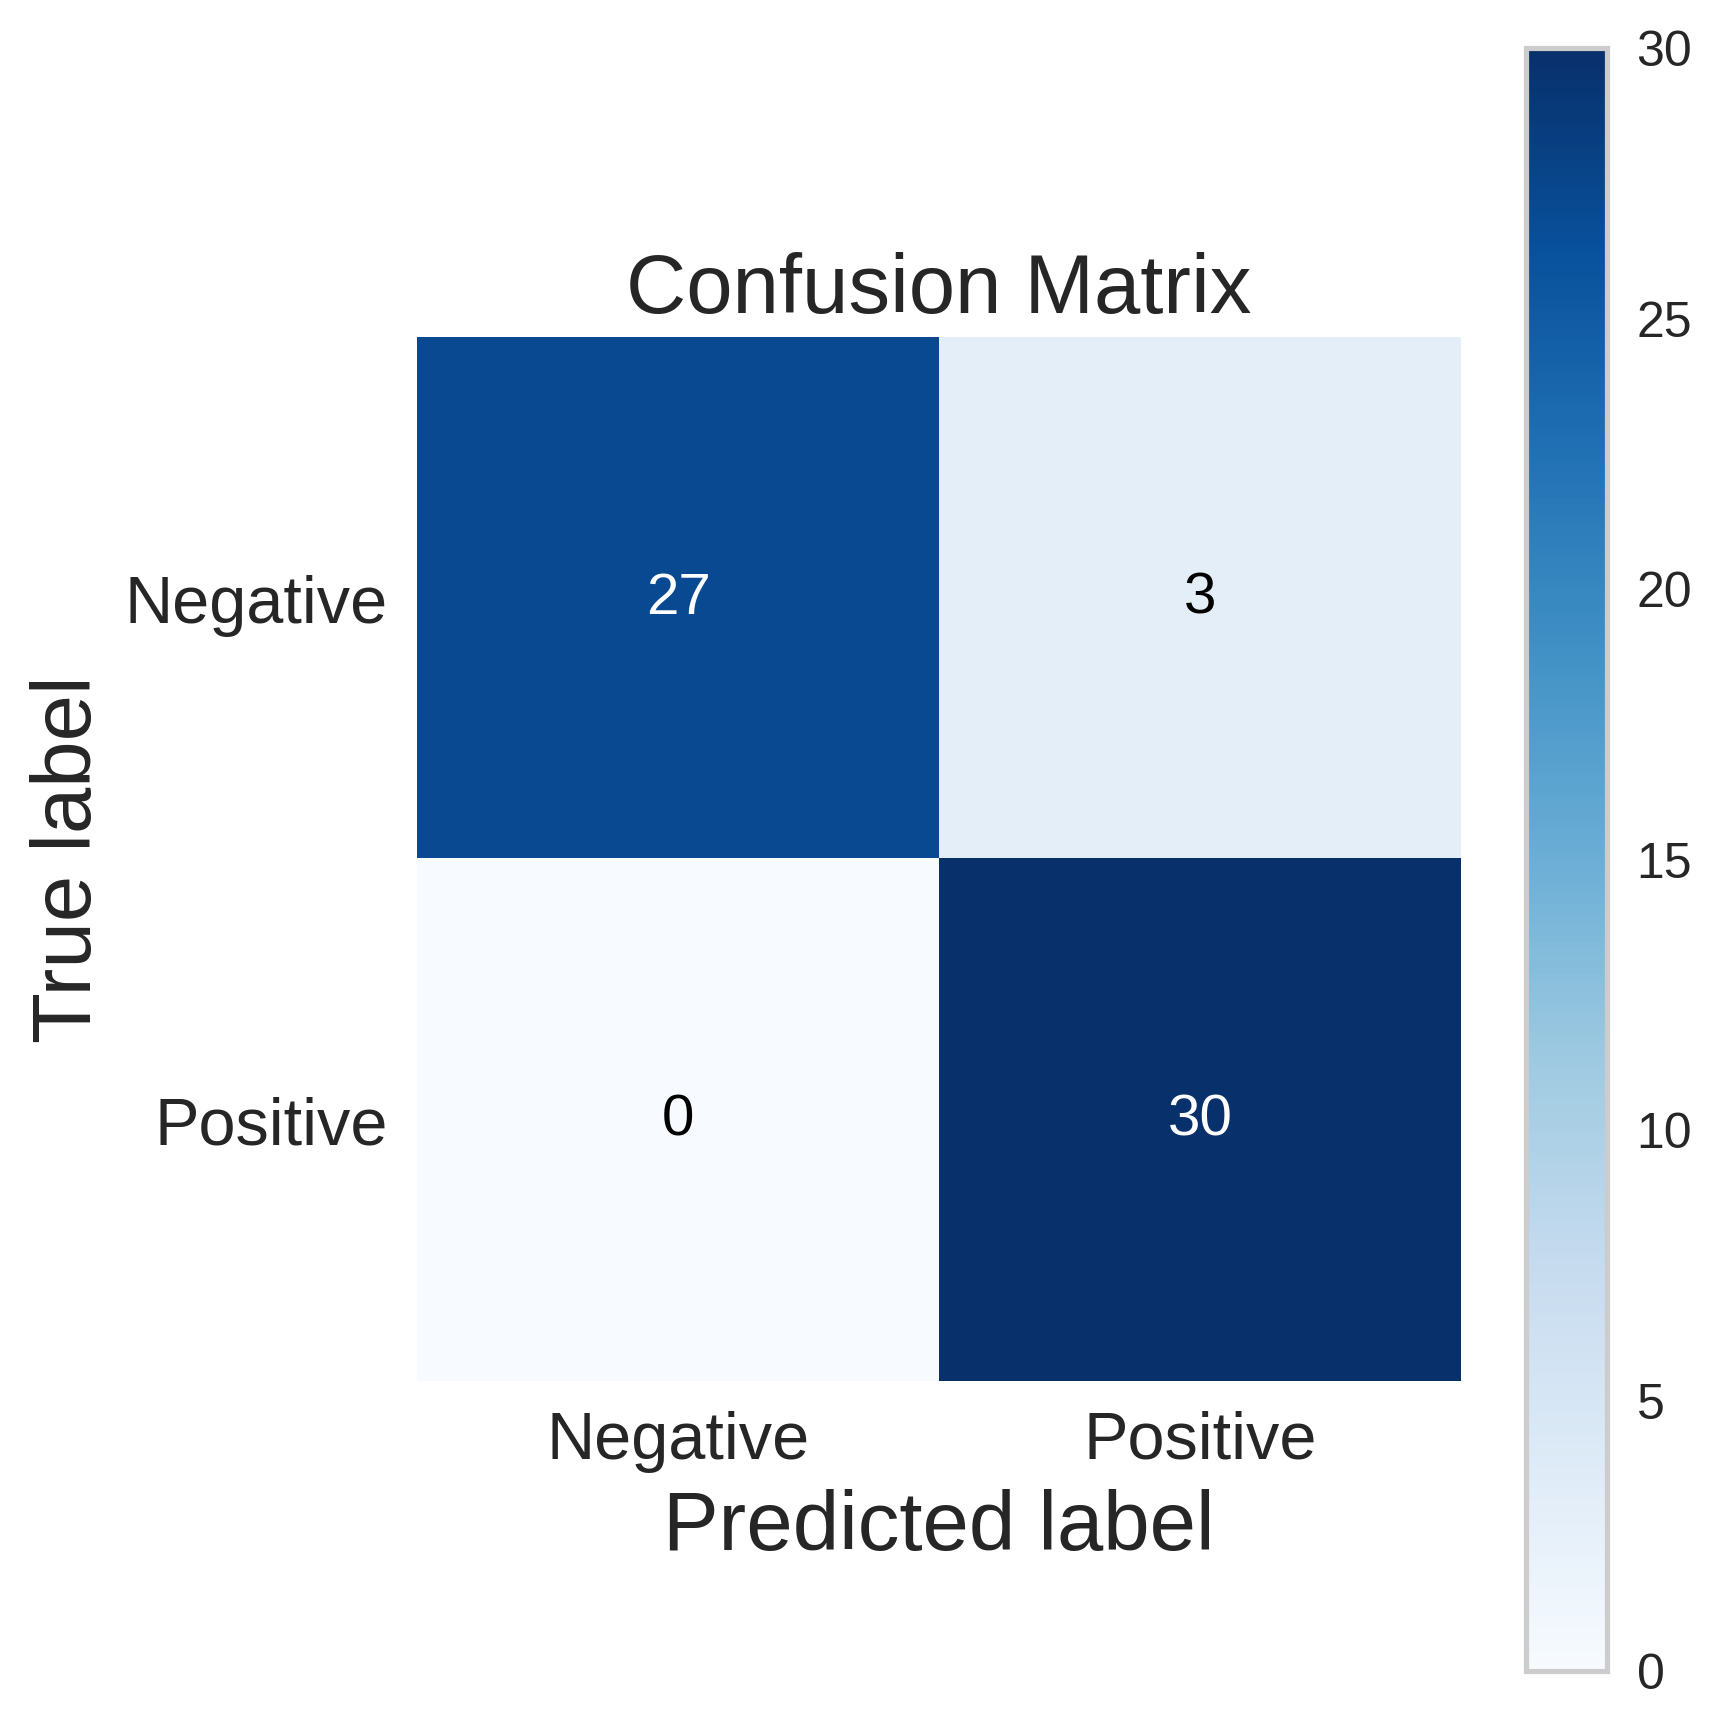

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# ===== confusion matrix =====
cm = confusion_matrix(y_true, y_pred)

# ===== figure =====
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# ===== heatmap =====
im = ax.imshow(cm, cmap=plt.cm.Blues)

# ===== text =====
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black",
            fontsize=14
        )


ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Negative', 'Positive'], fontsize=16)
ax.set_yticklabels(['Negative', 'Positive'], fontsize=16)

ax.set_xlabel("Predicted label", fontsize=20)
ax.set_ylabel("True label", fontsize=20)

ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=12)

ax.set_title("Confusion Matrix", fontsize=20)

plt.tight_layout()
plt.show()

In [57]:
# 1) Finalize the model by retraining it on the full dataset
model_final = finalize_model(tuned_model)

# 2) Access the underlying Random Forest classifier from the pipeline
rf = model_final.named_steps["actual_estimator"]

# 3) Obtain the feature names used during model training
feature_names = get_config("X_train").columns

# 4) feature importance
fi = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(fi.head(10))

,Feature,Importance
10,img_pca_0,0.215953
2,CRP,0.121696
0,WBC,0.104175
3,T-Bil,0.071602
7,ALP,0.033319
21,img_pca_11,0.032908
9,PT-INR,0.031004
5,ALT,0.030004
14,img_pca_4,0.027498
4,AST,0.019770


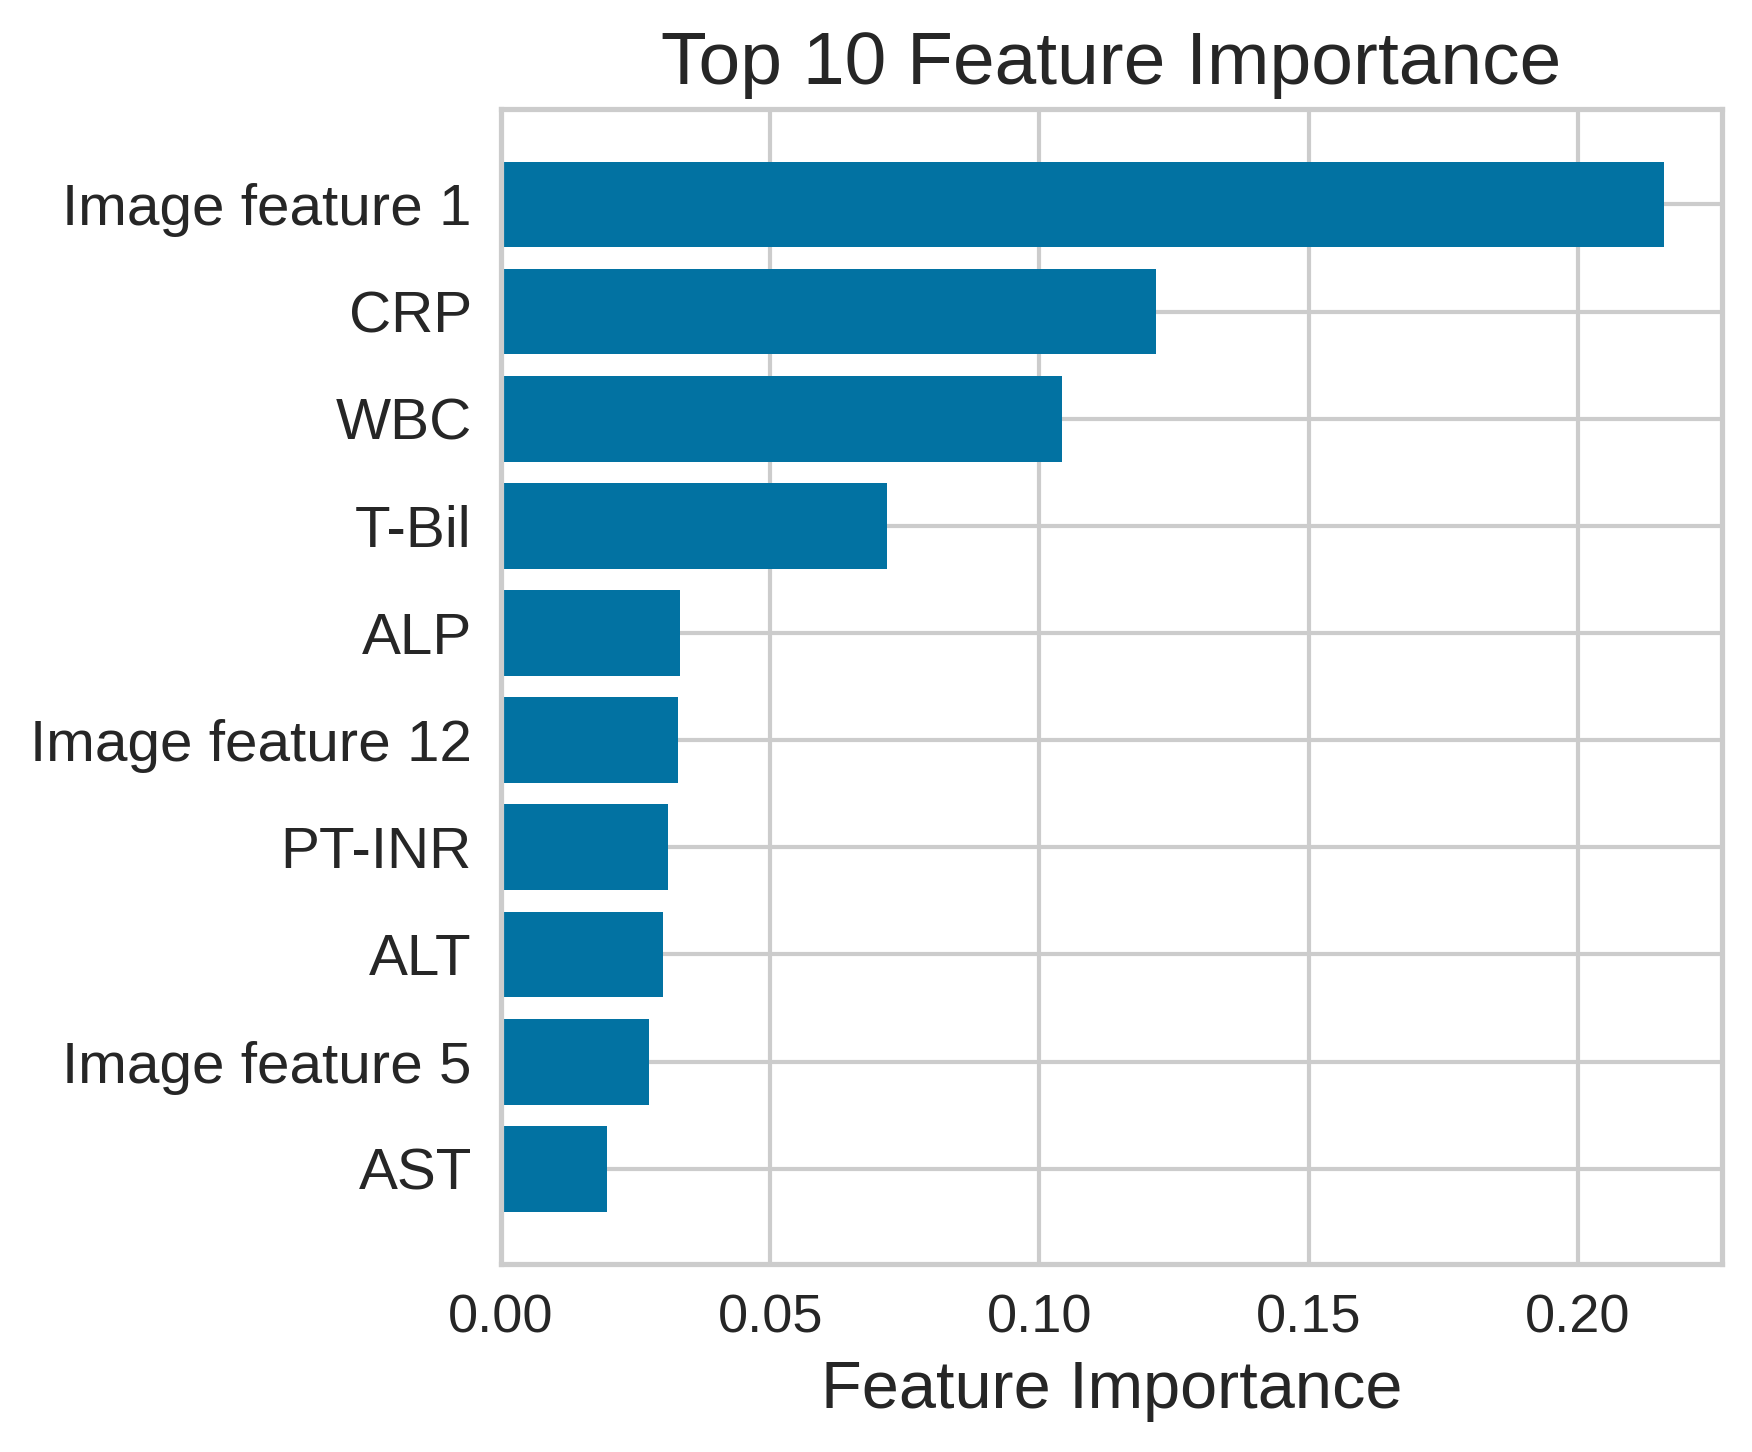

In [58]:
fi_top = fi.head(10).iloc[::-1].copy()

def rename_feature(x):
    if str(x).startswith("img_pca_"):
        num = int(x.split("_")[-1]) + 1
        return f"Image feature {num}"
    else:
        return x

fi_top["Feature"] = fi_top["Feature"].apply(rename_feature)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5), dpi=300)

plt.barh(fi_top["Feature"], fi_top["Importance"])

plt.xlabel("Feature Importance", fontsize=16)
plt.title("Top 10 Feature Importance", fontsize=18)

plt.xticks(fontsize=13)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

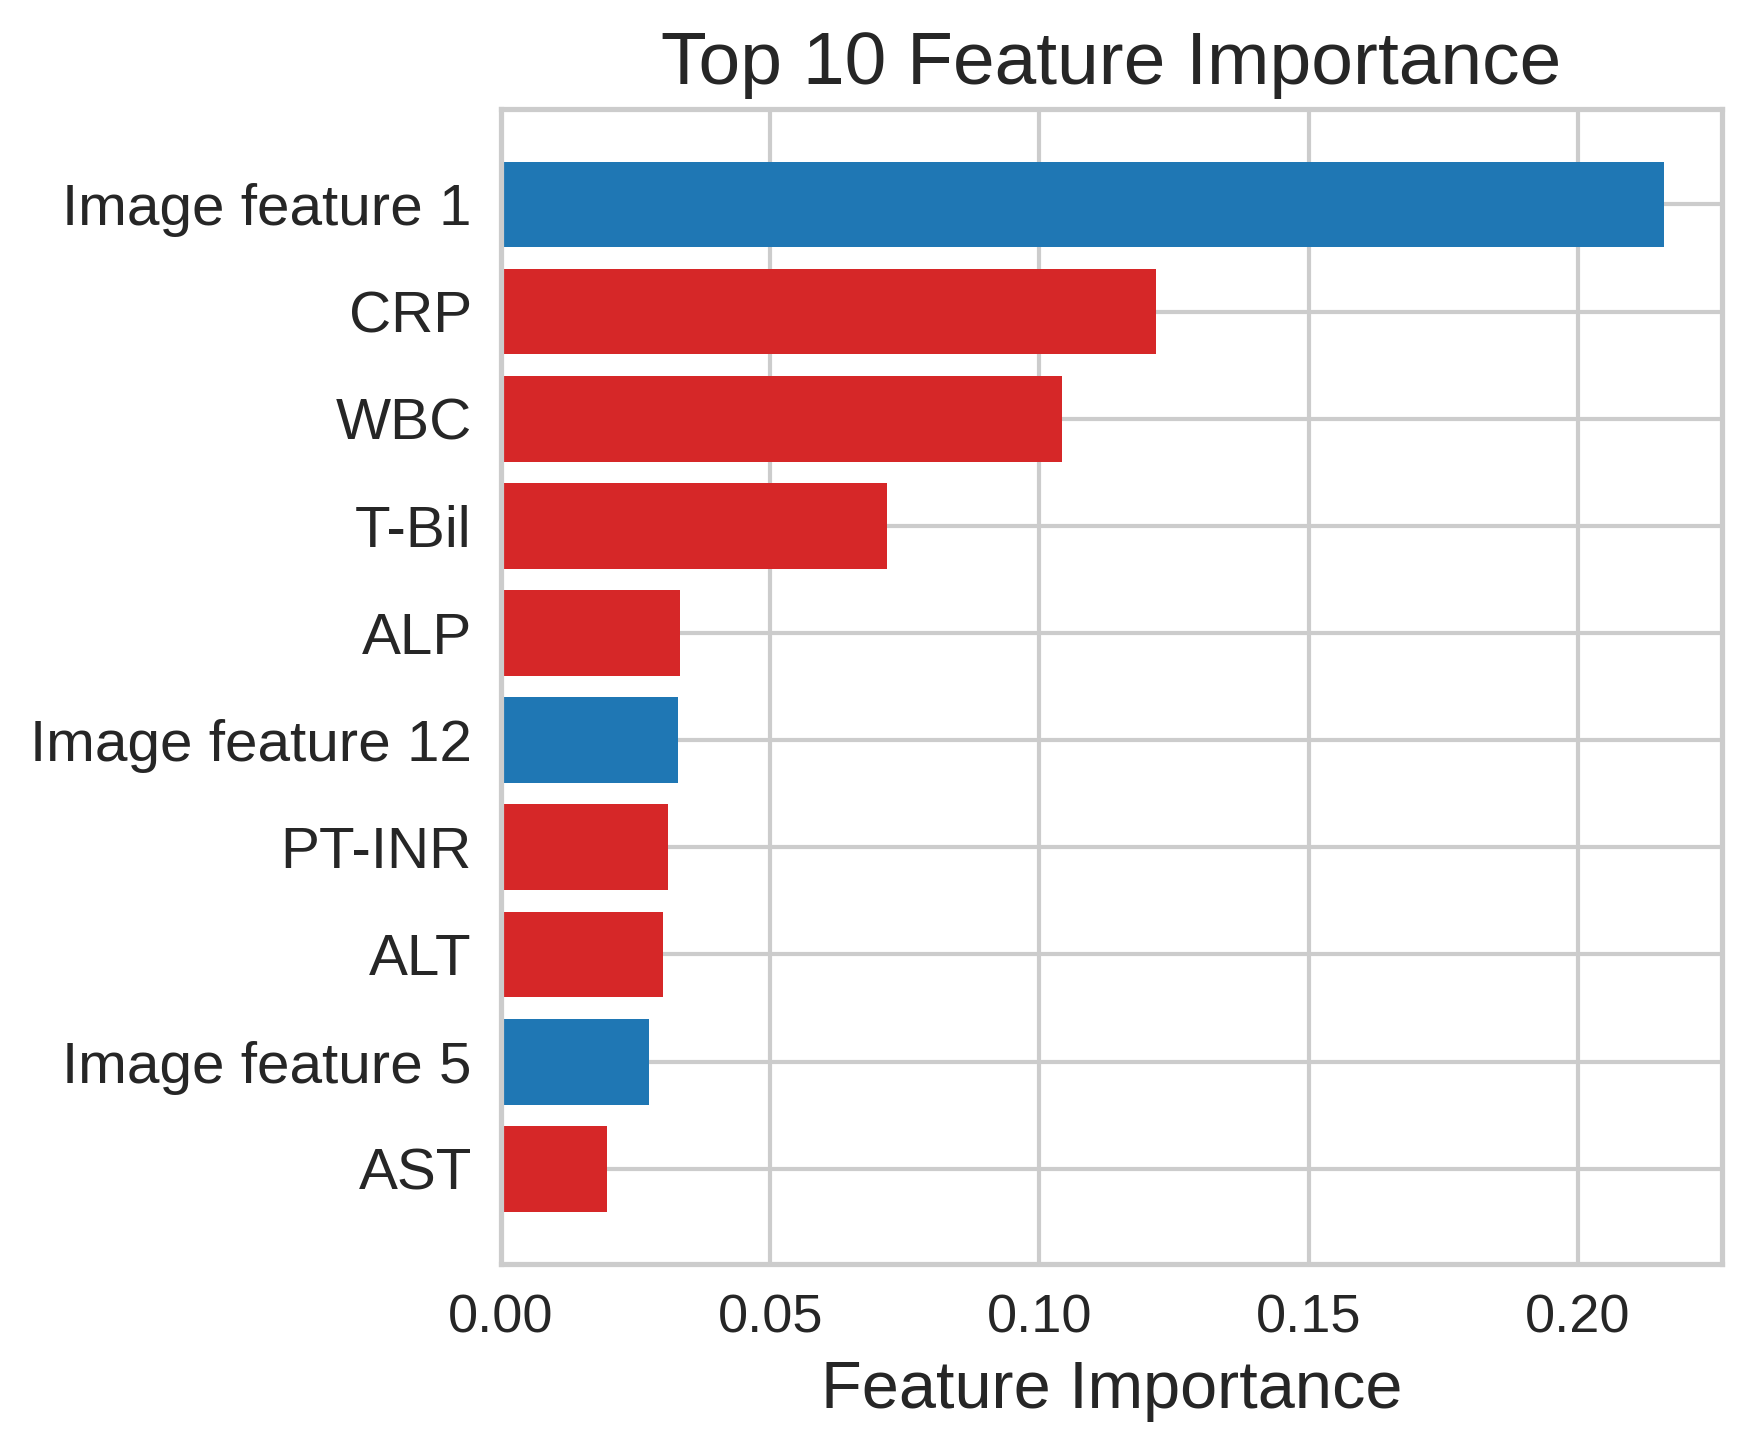

In [59]:
colors = [
    "tab:blue" if "Image feature" in f else "tab:red"
    for f in fi_top["Feature"]
]

plt.figure(figsize=(6, 5), dpi=300)
plt.barh(fi_top["Feature"], fi_top["Importance"], color=colors)

plt.xlabel("Feature Importance", fontsize=16)
plt.title("Top 10 Feature Importance", fontsize=18)

plt.xticks(fontsize=13)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()